<a href="https://colab.research.google.com/github/shahedEssa/graduation-project-real-/blob/noor/WorkingOnBaseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The model works in this sequence:

Training Phase

*  Only benign samples are used
*  Encoder compresses each sample into a latent distribution
*  Sampling selects a latent vector
*  Decoder reconstructs the sample List item
*  Loss = reconstruction loss + KL loss
*  The model learns the pattern of benign traffic

\
Validation Phase

*   Pass benign validation data
*   Calculate reconstruction errors
*   Select the threshold from the 99th percentile

\
Testing Phase

*   Benign test → to measure false positives
*   Attack data → to measure detection rate





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/CIC2023/"

df1 = pd.read_csv(path + "BenignTraffic.pcap.csv")
df2 = pd.read_csv(path + "BenignTraffic1.pcap.csv")
df3 = pd.read_csv(path + "BenignTraffic2.pcap.csv")
df4 = pd.read_csv(path + "BenignTraffic3.pcap.csv")

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [ ]:
print("Shape before cleaning:", df.shape, "\n")
print(df.head())

Shape before cleaning: (1098191, 39) 

   Header_Length  Protocol Type  Time_To_Live         Rate  fin_flag_number  \
0           32.0              6         198.4   430.273287              0.0   
1           22.4              6         114.4   484.616113              0.0   
2           27.2              6          62.5   398.610950              0.0   
3           23.2              6          62.1   425.187438              0.0   
4           32.0              6          64.0  1563.521956              0.0   

   syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  \
0              0.0              0.0              0.0              1.0   
1              0.0              0.0              0.2              0.6   
2              0.0              0.0              0.0              0.8   
3              0.1              0.0              0.0              0.6   
4              0.0              0.0              0.1              1.0   

   ece_flag_number  ...  LLC  Tot sum  Min   Ma

In [ ]:
print(df.dtypes)

Header_Length      float64
Protocol Type        int64
Time_To_Live       float64
Rate               float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count            int64
syn_count            int64
fin_count            int64
rst_count            int64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IGMP               float64
IPv                float64
LLC                float64
Tot sum              int64
Min                  int64
Max                  int64
AVG                float64
Std                float64
Tot size           float64
IAT                float64
N

In [ ]:
df_num = df.select_dtypes(include=[np.number]).copy()
print("Numeric shape:", df_num.shape)

Numeric shape: (1098191, 39)


In [ ]:
print("NaN count before cleaning:")
print(df_num.isnull().sum().sort_values(ascending=False).head(20), "\n")

print("Inf count before cleaning:")
print(np.isinf(df_num).sum())

NaN count before cleaning:
Std                65
Variance           65
Header_Length       0
Rate                0
fin_flag_number     0
Protocol Type       0
Time_To_Live        0
rst_flag_number     0
syn_flag_number     0
psh_flag_number     0
ack_flag_number     0
ack_count           0
syn_count           0
ece_flag_number     0
cwr_flag_number     0
HTTP                0
HTTPS               0
DNS                 0
Telnet              0
SMTP                0
dtype: int64 

Inf count before cleaning:
Header_Length       0
Protocol Type       0
Time_To_Live        0
Rate               65
fin_flag_number     0
syn_flag_number     0
rst_flag_number     0
psh_flag_number     0
ack_flag_number     0
ece_flag_number     0
cwr_flag_number     0
ack_count           0
syn_count           0
fin_count           0
rst_count           0
HTTP                0
HTTPS               0
DNS                 0
Telnet              0
SMTP                0
SSH                 0
IRC                 0
TCP    

In [ ]:
# =========================
# 3. Clean NaN / Inf
# =========================
df_num = df_num.replace([np.inf, -np.inf], np.nan)
print("Shape after replacing inf with NaN:", df_num.shape)

rows_before = df_num.shape[0]
df_num = df_num.dropna()
rows_after = df_num.shape[0]

print("Dropped rows:", rows_before - rows_after)
print("Shape after dropna:", df_num.shape)

Shape after replacing inf with NaN: (1098191, 39)
Dropped rows: 65
Shape after dropna: (1098126, 39)


In [ ]:
#  correlation
corr = df.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

df = df.drop(columns=to_drop)

print("Dropped features:", len(to_drop))

In [ ]:
# =========================
# 4. Split benign data
# =========================
train_df, temp_df = train_test_split(df_num, test_size=0.3, random_state=42)
val_df, test_benign_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train benign:", train_df.shape)
print("Validation benign:", val_df.shape)
print("Test benign:", test_benign_df.shape)

Train benign: (768688, 39)
Validation benign: (164719, 39)
Test benign: (164719, 39)


In [ ]:
print("Columns with very low uniqueness:")
print(df_num.nunique().sort_values().head(20))

# Do not drop constant columns automatically.
# A feature constant in benign traffic may vary under attack and therefore be useful for anomaly detection.
print("Skipping automatic constant-column removal to preserve potential attack-discriminative features.")

Columns with very low uniqueness:
Telnet              1
SMTP                1
IRC                 2
IGMP                3
Protocol Type       4
cwr_flag_number     5
ece_flag_number     6
SSH                 6
DHCP                9
fin_count           9
Number              9
ack_count          11
syn_count          11
rst_count          11
rst_flag_number    11
ICMP               13
fin_flag_number    16
syn_flag_number    16
IPv                19
LLC                19
dtype: int64
Skipping automatic constant-column removal to preserve potential attack-discriminative features.


In [ ]:
# =========================
# 5. Scale
# =========================
scaler = MinMaxScaler()

X_train = scaler.fit_transform(train_df)
X_val = scaler.transform(val_df)
X_test_benign = scaler.transform(test_benign_df)

print(X_train.shape, X_val.shape, X_test_benign.shape)

(768688, 39) (164719, 39) (164719, 39)


In [ ]:
model_dir = "/content/drive/MyDrive/CIC2023_saved/"
os.makedirs(model_dir, exist_ok=True)

weights_path = os.path.join(model_dir, "vae_weights.weights.h5")
scaler_path = os.path.join(model_dir, "scaler.pkl")
threshold_path = os.path.join(model_dir, "threshold.npy")
columns_path = os.path.join(model_dir, "feature_columns.pkl")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
input_dim = X_train.shape[1]
latent_dim = 8

In [ ]:
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-5))(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Sampling()([z_mean, z_log_var])

In [ ]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-5))(latent_inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-5))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

In [ ]:
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=0.5, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=1)
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )

            total_loss = reconstruction_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
          z_mean, z_log_var, z = self.encoder(inputs)
          return self.decoder(z)


    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(data - reconstruction), axis=1)
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = reconstruction_loss + self.beta * kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [ ]:
def get_anomaly_scores(model, data, alpha=1.0, beta_kl_score=0.1, use_mean=True):
    z_mean, z_log_var, z = model.encoder(data)

    latent = z_mean if use_mean else z
    reconstruction = model.decoder(latent)

    reconstruction_error = np.mean(np.square(data - reconstruction), axis=1)

    kl_per_sample = -0.5 * np.sum(
        1 + z_log_var.numpy() - np.square(z_mean.numpy()) - np.exp(z_log_var.numpy()),
        axis=1
    )

    combined_score = alpha * reconstruction_error + beta_kl_score * kl_per_sample

    return reconstruction_error, kl_per_sample, combined_score

In [ ]:
force_retrain = True

vae = VAE(encoder, decoder, beta=0.5)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

# Build the subclassed model once
_ = vae(tf.convert_to_tensor(X_train[:1], dtype=tf.float32))

if (
    not force_retrain
    and os.path.exists(weights_path)
    and os.path.exists(scaler_path)
    and os.path.exists(threshold_path)
    and os.path.exists(columns_path)
):
    vae.load_weights(weights_path)
    scaler = joblib.load(scaler_path)
    threshold = np.load(threshold_path)
    saved_columns = joblib.load(columns_path)
    print("Loaded saved model, scaler, threshold, and feature columns.")

else:
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        mode="min",
        patience=5,
        restore_best_weights=True
    )

    history = vae.fit(
        X_train,
        validation_data=(X_val, None),
        epochs=50,
        batch_size=256,
        callbacks=[early_stopping]
    )

    val_recon, val_kl, val_scores = get_anomaly_scores(
        vae,
        X_val,
        alpha=1.0,
        beta_kl_score=0.1
    )

    threshold = np.percentile(val_scores, 90)


Epoch 1/50
3003/3003 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step - kl_loss: 1.0773 - reconstruction_loss: 0.2439 - total_loss: 0.3517 - val_kl_loss: 1.1824 - val_reconstruction_loss: 0.1700 - val_total_loss: 0.2882
Epoch 2/50
3003/3003 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - kl_loss: 1.1534 - reconstruction_loss: 0.1715 - total_loss: 0.2868 - val_kl_loss: 1.1786 - val_reconstruction_loss: 0.1665 - val_total_loss: 0.2843
Epoch 3/50
3003/3003 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - kl_loss: 1.1693 - reconstruction_loss: 0.1680 - total_loss: 0.2850 - val_kl_loss: 1.1910 - val_reconstruction_loss: 0.1645 - val_total_loss: 0.2836
Epoch 4/50
3003/3003 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - kl_loss: 1.1724 - reconstruction_loss: 0.1668 - total_loss: 0.2841 - val_kl_loss: 1.1395 - val_reconstruction_loss: 0.1693 - val_total_loss: 0.2832
Epoch 5/50
3003/3003 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - kl_loss: 1.1753 - reconstruction_loss: 0.1662 - total_loss: 0.2837 - val_kl_loss: 1.1233 - val_reconstruction_loss: 0.1710 

In [ ]:
best_val_loss = min(history.history["val_total_loss"])
print(best_val_loss)

0.2812238037586212


In [ ]:
'''vae.save_weights(weights_path)
joblib.dump(scaler, scaler_path)
np.save(threshold_path, threshold)
joblib.dump(list(df_num.columns), columns_path)'''

['/content/drive/MyDrive/CIC2023_saved/feature_columns.pkl']

In [ ]:
'''from google.colab import drive
drive.mount('/content/drive')

import pickle

history_path = "/content/drive/MyDrive/vae_history.pkl"

with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

import os
print(os.path.getsize(history_path))'''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
844


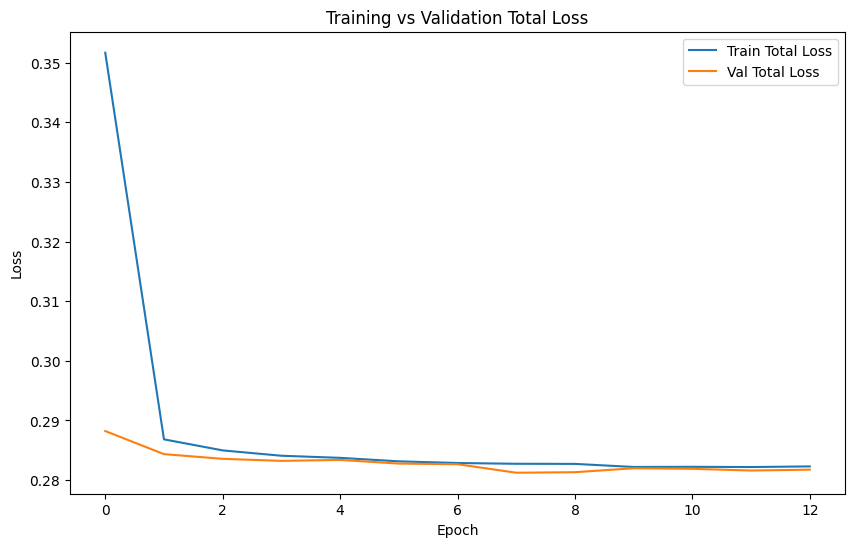

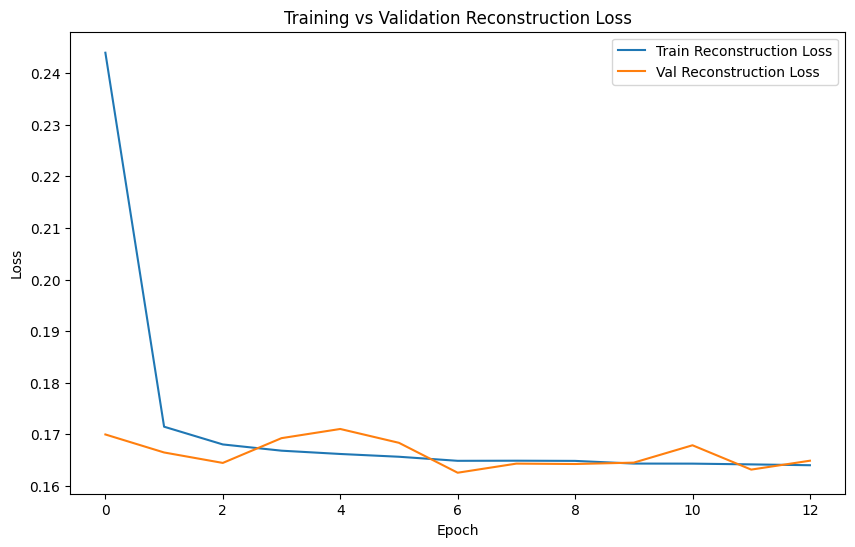

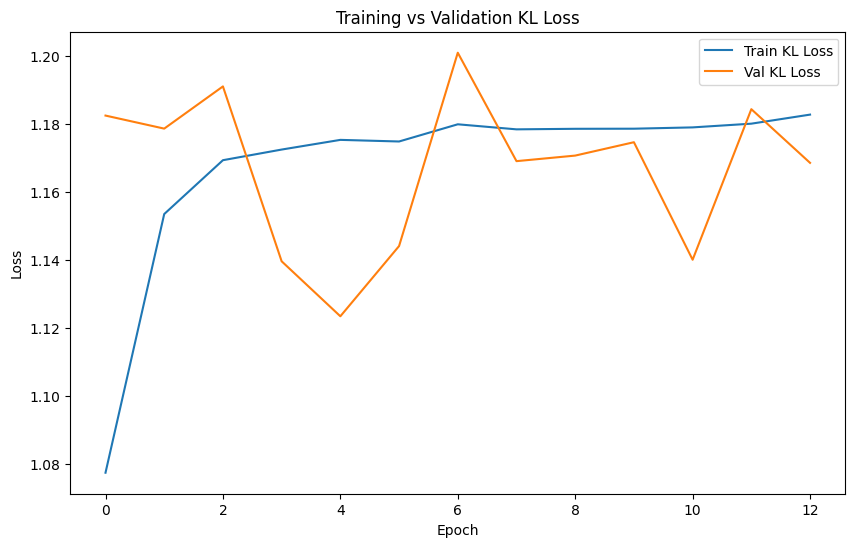

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history["total_loss"], label="Train Total Loss")
plt.plot(history.history["val_total_loss"], label="Val Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history["reconstruction_loss"], label="Train Reconstruction Loss")
plt.plot(history.history["val_reconstruction_loss"], label="Val Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Reconstruction Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history["kl_loss"], label="Train KL Loss")
plt.plot(history.history["val_kl_loss"], label="Val KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation KL Loss")
plt.legend()
plt.show()

In [ ]:
# Use unseen benign validation samples to measure normal reconstruction errors.
# Set threshold as the maximum acceptable normal error.
# If a future sample error exceeds the threshold -> classify as attack/anomaly.
# Otherwise -> classify as benign.

val_recon, val_kl, val_scores = get_anomaly_scores(
    vae,
    X_val,
    alpha=1.0,
    beta_kl_score=0.1
)

print("Validation reconstruction stats:")
print("Min:", val_recon.min())
print("Max:", val_recon.max())
print("Mean:", val_recon.mean())

print("\nValidation KL stats:")
print("Min:", val_kl.min())
print("Max:", val_kl.max())
print("Mean:", val_kl.mean())

print("\nValidation combined score stats:")
print("Min:", val_scores.min())
print("Max:", val_scores.max())
print("Mean:", val_scores.mean())

Validation reconstruction stats:
Min: 0.000103293525
Max: 0.14932725
Mean: 0.0031741534

Validation KL stats:
Min: 0.25788403
Max: 4.8568993
Mean: 1.1689515

Validation combined score stats:
Min: 0.034887444
Max: 0.5181685
Mean: 0.1200693


In [ ]:
# Set threshold at the 90 percentile of benign validation errors

val_recon, val_kl, val_scores = get_anomaly_scores(
    vae,
    X_val,
    alpha=1.0,
    beta_kl_score=0.1
)

threshold = np.percentile(val_scores, 90)
print("Threshold:", threshold)


Threshold: 0.28449267


In [ ]:
vae.save_weights(weights_path)
joblib.dump(scaler, scaler_path)
np.save(threshold_path, threshold)
joblib.dump(list(df_num.columns), columns_path)

['/content/drive/MyDrive/CIC2023_saved/feature_columns.pkl']

In [ ]:
# Since all test samples are benign, any predicted attack is a false positive.
# This measures the false alarm rate.

test_benign_recon, test_benign_kl, test_benign_scores = get_anomaly_scores(
    vae,
    X_test_benign,
    alpha=1.0,
    beta_kl_score=0.1
)

test_benign_pred = (test_benign_scores > threshold).astype(int)


false_positives = test_benign_pred.sum()

print("False positives on benign test:", false_positives)
print("False positive rate:", false_positives / len(test_benign_pred))

False positives on benign test: 16627
False positive rate: 0.1009416035794292


In [ ]:
import os
import pandas as pd
import numpy as np

attack_path = "/content/drive/MyDrive/MERGED_CSV(CIC2023)/MERGED_CSV/"
files = sorted(os.listdir(attack_path))

per_class_n = 3000
sampled_parts = []

for file in files:
    if file.endswith(".csv"):
        print(f"Reading {file} ...")

        temp = pd.read_csv(attack_path + file)

        # Keep only attack rows
        if "Label" not in temp.columns:
            print(f"Skipping {file}: no Label column")
            continue

        temp = temp[temp["Label"] != "BENIGN"]

        if len(temp) == 0:
            continue

        # Balanced sampling inside this file
        temp_sampled = (
            temp.groupby("Label", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), per_class_n), random_state=42))
            .reset_index(drop=True)
        )

        sampled_parts.append(temp_sampled)

        print(f"Kept {len(temp_sampled)} rows from {file}")

df_attack = pd.concat(sampled_parts, ignore_index=True)

print("\nFinal sampled attack shape:", df_attack.shape)
print(df_attack["Label"].value_counts())

Reading Merged01.csv ...


/tmp/ipykernel_1258/746378693.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), per_class_n), random_state=42))


Kept 63943 rows from Merged01.csv
Reading Merged02.csv ...


/tmp/ipykernel_1258/746378693.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), per_class_n), random_state=42))


Kept 64670 rows from Merged02.csv
Reading Merged03.csv ...


...

Kept 63986 rows from Merged61.csv
Reading Merged62.csv ...


/tmp/ipykernel_1258/746378693.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), per_class_n), random_state=42))


Kept 63863 rows from Merged62.csv
Reading Merged63.csv ...


/tmp/ipykernel_1258/746378693.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), per_class_n), random_state=42))


Kept 59062 rows from Merged63.csv

Final sampled attack shape: (4001653, 40)
Label
DDOS-PSHACK_FLOOD          189000
DOS-TCP_FLOOD              189000
DDOS-RSTFINFLOOD           189000
DDOS-ICMP_FLOOD            189000
DDOS-SYNONYMOUSIP_FLOOD    189000
DDOS-UDP_FLOOD             189000
DDOS-TCP_FLOOD             189000
DDOS-SYN_FLOOD             189000
DOS-UDP_FLOOD              189000
DOS-SYN_FLOOD              188743
MIRAI-GREETH_FLOOD         187344
MIRAI-UDPPLAIN             187250
MIRAI-GREIP_FLOOD          187070
DDOS-ICMP_FRAGMENTATION    185676
VULNERABILITYSCAN          185251
MITM-ARPSPOOFING           184773
DDOS-ACK_FRAGMENTATION     184401
DDOS-UDP_FRAGMENTATION     184395
DNS_SPOOFING               167095
RECON-HOSTDISCOVERY        128677
RECON-OSSCAN                93970
RECON-PORTSCAN              78730
DOS-HTTP_FLOOD              68799
DDOS-HTTP_FLOOD             27597
DDOS-SLOWLORIS              22400
DICTIONARYBRUTEFORCE        12522
BROWSERHIJACKING             5630

In [ ]:
labels_attack = df_attack["Label"].copy()

df_attack_features = df_attack.replace([np.inf, -np.inf], np.nan)
df_attack_features = df_attack_features.dropna()

labels_attack = labels_attack.loc[df_attack_features.index]

df_attack_features = df_attack_features.select_dtypes(include=[np.number])
df_attack_features = df_attack_features[df_num.columns]

In [ ]:
import numpy as np

def get_anomaly_scores_in_batches(model, data, batch_size=2048, alpha=1.0, beta_kl_score=0.1, use_mean=True):
    all_recon = []
    all_kl = []
    all_scores = []

    n = len(data)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = data[start:end]

        z_mean, z_log_var, z = model.encoder(batch)

        latent = z_mean if use_mean else z
        reconstruction = model.decoder(latent)

        reconstruction_error = np.mean(np.square(batch - reconstruction.numpy()), axis=1)

        kl_per_sample = -0.5 * np.sum(
            1 + z_log_var.numpy() - np.square(z_mean.numpy()) - np.exp(z_log_var.numpy()),
            axis=1
        )

        combined_score = alpha * reconstruction_error + beta_kl_score * kl_per_sample

        all_recon.append(reconstruction_error)
        all_kl.append(kl_per_sample)
        all_scores.append(combined_score)

    return (
        np.concatenate(all_recon),
        np.concatenate(all_kl),
        np.concatenate(all_scores)
    )

In [ ]:
X_attack = scaler.transform(df_attack_features)

attack_recon, attack_kl, attack_scores = get_anomaly_scores_in_batches(
    vae,
    X_attack,
    batch_size=1024,
    alpha=1.0,
    beta_kl_score=0.1
)

attack_pred = (attack_scores > threshold).astype(int)

print("Detected attacks:", attack_pred.sum())
print("Attack detection rate:", attack_pred.mean())

/tmp/ipykernel_1258/3817551537.py:22: RuntimeWarning: overflow encountered in exp
  1 + z_log_var.numpy() - np.square(z_mean.numpy()) - np.exp(z_log_var.numpy()),


Detected attacks: 3354193
Attack detection rate: 0.8382370544935193


In [ ]:
df_attack_eval = pd.DataFrame({
    "Label": labels_attack.values,
    "Predicted_Attack": attack_pred
})

per_class_results = (
    df_attack_eval.groupby("Label")["Predicted_Attack"]
    .agg(
        Total_Samples="count",
        Detected_Attacks="sum",
        Detection_Rate="mean"
    )
)

per_class_results["Detection_%"] = (
    per_class_results["Detection_Rate"] * 100
).round(2)

print(per_class_results.sort_values("Detection_Rate", ascending=False))

                         Total_Samples  Detected_Attacks  Detection_Rate  \
Label                                                                      
DDOS-ICMP_FLOOD                 188999            188999        1.000000   
MIRAI-GREIP_FLOOD               187057            187057        1.000000   
DDOS-UDP_FLOOD                  188999            188999        1.000000   
MIRAI-UDPPLAIN                  187231            187231        1.000000   
MIRAI-GREETH_FLOOD              187335            187334        0.999995   
DDOS-SYN_FLOOD                  188995            188993        0.999989   
DDOS-RSTFINFLOOD                188998            188995        0.999984   
DOS-UDP_FLOOD                   188987            188984        0.999984   
DDOS-UDP_FRAGMENTATION          184374            184368        0.999967   
DDOS-SYNONYMOUSIP_FLOOD         188998            188989        0.999952   
DOS-TCP_FLOOD                   188996            188986        0.999947   
DOS-SYN_FLOO

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = np.concatenate([
    np.zeros(len(test_benign_pred)),
    np.ones(len(attack_pred))
])

y_pred = np.concatenate([
    test_benign_pred,
    attack_pred
])

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[ 148092   16627]
 [ 647292 3354193]]
              precision    recall  f1-score   support

         0.0       0.19      0.90      0.31    164719
         1.0       1.00      0.84      0.91   4001485

    accuracy                           0.84   4166204
   macro avg       0.59      0.87      0.61   4166204
weighted avg       0.96      0.84      0.89   4166204

